# **Análisis exploratorio de datos**

## Importar librerias

In [580]:
# Importar librerias
import pandas as pd
from datetime import datetime
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
from lifelines import KaplanMeierFitter

## Importar bases de datos

In [581]:
df_orders = pd.read_csv('data/raw/orders_data.csv')

df_stores = pd.read_csv('data/raw/stores_data.csv')

In [582]:
df_orders.head()

,created_date,APP_ORIGIN,markdown,free_shipping_flag,promedio_shipping_cost,store_id,TPN,TPV,GMV_LC,month,year
0,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,113911.0,2,41200.0,20600.0,1,2024
1,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.09,113087.0,2,13000.0,13000.0,1,2024
2,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.96,107298.0,34,405200.0,229200.0,1,2024
3,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,112366.0,2,138000.0,23000.0,1,2024
4,2024-01-01,MP_IOS_WALLET,0.0,1,1015.07,115169.0,6,34000.0,34000.0,1,2024


In [583]:
df_stores.head()

,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,active,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060.0,107643
1,2025-09-16T22:10:44.806Z,active,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049.0,100827
2,2025-09-16T21:24:41.804Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689.0,107223
3,2025-09-16T21:09:19.795Z,active,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955.0,102438
4,2025-09-16T21:08:58.784Z,active,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502.0,112782


In [584]:
print(f'Columnas de df_orders: {df_orders.columns}')
print(f'Columnas de df_stores: {df_stores.columns}')

Columnas de df_orders: Index(['created_date', 'APP_ORIGIN', 'markdown', 'free_shipping_flag',
       'promedio_shipping_cost', 'store_id', 'TPN', 'TPV', 'GMV_LC', 'month',
       'year'],
      dtype='object')
Columnas de df_stores: Index(['created_date', 'status', 'segmento', 'comision_actual',
       'logistic_type', 'store_type', 'barrio', 'category', 'cooking_time',
       'tiene_otra_app', 'brand_id', 'store_id'],
      dtype='object')


In [585]:
# Renombrar columnas para practicidad

df_orders.rename(columns={'created_date': 'orders_date',
                          'APP_ORIGIN': 'app_origin',
                          'promedio_shipping_cost': 'avg_shipping_cost',
                          'free_shipping_flag': 'free_shipping',
                          'TPN': 'tpn',
                          'TPV': 'tpv',
                          'GMV_LC': 'gmv'
                          }, inplace=True)

## Data cleaning

### *df_stores*

In [586]:
df_stores.head()

,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,active,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060.0,107643
1,2025-09-16T22:10:44.806Z,active,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049.0,100827
2,2025-09-16T21:24:41.804Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689.0,107223
3,2025-09-16T21:09:19.795Z,active,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955.0,102438
4,2025-09-16T21:08:58.784Z,active,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502.0,112782


Vemos tema duplicados

In [587]:
# Partimos de df_stores original (puede llamarse igual en tu entorno)
df_stores_orig = df_stores.copy()

# 1) Agrupar por store_id y tomar la "fila combinada" aplicando bfill() y tomando la primera fila
df_stores_clean = (
    df_stores_orig
    .groupby('store_id', sort=False)        # mantiene el orden original de aparición
    .apply(lambda g: g.bfill().iloc[0])    # rellenar NaN hacia arriba y tomar la primera fila resultante
    .reset_index(drop=True)                # si preferís mantener store_id como columna, usar reset_index()
)

/var/folders/3y/gthkm3q95_s8ph7_t5zg1wb00000gn/T/ipykernel_3217/3587922541.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda g: g.bfill().iloc[0])    # rellenar NaN hacia arriba y tomar la primera fila resultante
/var/folders/3y/gthkm3q95_s8ph7_t5zg1wb00000gn/T/ipykernel_3217/3587922541.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.bfill().iloc[0])    # rellenar NaN hacia arriba y tomar la primera fila resultante


In [588]:
# 2) Verificar que ahora hay 1 fila por store_id
n_unique_before = df_stores_orig['store_id'].nunique()
n_rows_after = len(df_stores_clean)
print(f"stores únicos antes: {n_unique_before}, filas resultantes: {n_rows_after}")

stores únicos antes: 9956, filas resultantes: 9956


In [589]:
# 3) (Opcional) mostrar ejemplos:  before vs after para 5 stores que estaban duplicadas
dups = df_stores_orig.groupby('store_id').size().reset_index(name='cnt').query('cnt>1')
sample = dups['store_id'].head(5).tolist()

for sid in sample:
    print("=== STORE:", sid, "===\nORIGINAL:")
    display(df_stores_orig[df_stores_orig['store_id']==sid])
    print("=> CLEANED:")
    display(df_stores_clean[df_stores_clean['store_id']==sid])

=== STORE: 100056 ===
ORIGINAL:


,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
8003,2024-07-31T15:58:22.363Z,active,Microstores,42.0,3P,New brand,OLIVOS,Panadería,20 min,Sí,NaN,100056
8004,2024-07-31T15:58:22.363Z,active,Microstores,42.0,3P,New brand,OLIVOS,Panadería,20 min,Sí,NaN,100056


=> CLEANED:


,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
7992,2024-07-31T15:58:22.363Z,active,Microstores,42.0,3P,New brand,OLIVOS,Panadería,20 min,Sí,NaN,100056


=== STORE: 100121 ===
ORIGINAL:


...

,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
5771,2025-01-30T13:36:20.038Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Arepas,20 min,Sí,10865.0,100325


=== STORE: 100441 ===
ORIGINAL:


,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
9077,2024-05-02T23:05:50.668Z,active,Microstores,42.0,3P,New brand,BOEDO,Argentina,20 min,No,10108.0,100441
9078,2024-05-02T23:05:50.668Z,active,Microstores,NaN,3P,NaN,BOEDO,Argentina,20 min,NaN,10108.0,100441


=> CLEANED:


,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
9063,2024-05-02T23:05:50.668Z,active,Microstores,42.0,3P,New brand,BOEDO,Argentina,20 min,No,10108.0,100441


In [590]:
df_stores = df_stores_clean.copy()

#### *status*

In [591]:
pd.DataFrame({'count': df_stores['status'].value_counts(dropna=False), 'percentage': (df_stores['status'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
status,,
active,9894,99.38
inactive,53,0.53
paused,9,0.09


Solo nos interesan aquellos locales activos

In [592]:
# Filtrar df_stores para quedarse solo con los registros con STATUS 'active'
df_stores = df_stores[df_stores['status'] == 'active']

if 'status' in df_stores.columns:
    df_stores.drop(columns=['status'], inplace=True)

#### *brand_id*

In [593]:
pd.DataFrame({'missing_count': df_stores.isnull().sum(), 'missing_pct': (df_stores.isnull().sum()/len(df_stores)*100).round(2)}).query("missing_count>0").sort_values('missing_count', ascending=False)

,missing_count,missing_pct
brand_id,1994,20.15
barrio,950,9.60
category,719,7.27
comision_actual,422,4.27
cooking_time,357,3.61
store_type,308,3.11
tiene_otra_app,308,3.11
segmento,1,0.01


Hay 2012 valores faltantes en la columna *brand_id*. Esto se debe a que muchos stores son locales pequeños con un unico local, en lugar de una marca grande con multiples stores/sucursales como mcdondalds por ejemplo

In [594]:
# Encontrar el valor más grande de brand_id ignorando NaN
max_brand_id = df_stores['brand_id'].dropna().max()

# Crear un contador que empieza en el siguiente entero al máximo brand_id
contador = int(max_brand_id) + 1

# Asignar un brand_id nuevo a cada registro sin brand_id
# Creamos una máscara para los registros con brand_id nulo
mask_na = df_stores['brand_id'].isna()

# Asignar valores únicos a cada registro sin brand_id
df_stores.loc[mask_na, 'brand_id'] = range(contador, contador + mask_na.sum())

# Convertir brand_id a int para evitar decimales
df_stores['brand_id'] = df_stores['brand_id'].astype(int)

#### *creation_date*

In [595]:
df_stores.head()

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16T22:10:44.806Z,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16T21:24:41.804Z,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16T21:09:19.795Z,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16T21:08:58.784Z,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


In [596]:
# Guardar la columna original
df_stores['creation_date_original'] = df_stores['created_date']

# fuerza parseo a UTC (aware) y luego removemos la info de tz
df_stores["created_date"] = pd.to_datetime(df_stores["created_date"], errors="coerce", utc=True).dt.tz_convert("UTC").dt.tz_localize(None).dt.normalize()

In [597]:
# Ver años, meses y días únicos
print("Años únicos:", df_stores['created_date'].dt.year.unique())
print("Meses únicos:", df_stores['created_date'].dt.month.unique())
print("Días únicos:", df_stores['created_date'].dt.day.unique())

Años únicos: [2025 2024]
Meses únicos: [ 9  8  7  6  5  4  3  2  1 12 11 10]
Días únicos: [16 15  4  3  2 29 28 27 26 25 21 20 19 18 14 13 12 11  8  7  6  5  1 31
 30 24 23 22 17  9 10]


In [598]:
df_stores.drop(columns=['creation_date_original'], inplace=True)

In [599]:
df_stores.head()

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


#### *segmento*

In [600]:
pd.DataFrame({'count': df_stores['segmento'].value_counts(dropna=False), 'percentage': (df_stores['segmento'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
segmento,,
Microstores,6951,70.25
Top Players,1604,16.21
Picked Locals,1336,13.50
0,2,0.02
NaN,1,0.01


In [601]:
# Filas donde segmento es 0 o NaN
segmento_0_nan = df_stores[(df_stores['segmento'] == "0") | (df_stores['segmento'].isna())]

segmento_0_nan

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
5923,2025-01-17,0,36.0,3P,Brand expansion,BELGRANO,Empanadas,15 min,Sí,12808,104747
6999,2024-10-18,0,27.0,3P,New brand,PALERMO,Helado,15 min,Sí,13326,107259
9196,2024-04-20,NaN,19.5,2P,Brand expansion,BELGRANO,Sushi,NaN,Sí,12228,106165


In [602]:
# Verificar si los registros en segmento_0_nan tienen brand_id que aparecen en otros registros de df_stores
for idx, row in segmento_0_nan.iterrows():
    brand_id = row['brand_id']
    count = df_stores[df_stores['brand_id'] == brand_id].shape[0]
    print(f"brand_id {brand_id} aparece en {count} registro(s) en df_stores")

brand_id 12808 aparece en 3 registro(s) en df_stores
brand_id 13326 aparece en 87 registro(s) en df_stores
brand_id 12228 aparece en 7 registro(s) en df_stores


In [603]:
df_stores[df_stores['brand_id'] == segmento_0_nan.iloc[0]['brand_id']]

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
5922,2025-01-17,Picked Locals,36.0,3P,Brand expansion,ALMAGRO,Empanadas,15 min,Sí,12808,109220
5923,2025-01-17,0,36.0,3P,Brand expansion,BELGRANO,Empanadas,15 min,Sí,12808,104747
5927,2025-01-17,Picked Locals,36.0,3P,New brand,MATADEROS,Empanadas,15 min,Sí,12808,103999


In [604]:
df_stores[df_stores['brand_id'] == segmento_0_nan.iloc[1]['brand_id']]

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
161,2025-08-15,Top Players,27.0,3P,Brand expansion,MANANTIALES,Helado,10 min,Sí,13326,100385
549,2025-08-05,Top Players,27.0,3P,Brand expansion,JARDIN DEL SUD,Helado,10 min,Sí,13326,109149
592,2025-08-04,Top Players,27.0,3P,Brand expansion,VILLA MAIPÚ,Helado,10 min,Sí,13326,112082
595,2025-08-04,Top Players,27.0,3P,Brand expansion,VILLA MAIPÚ,Helado,10 min,Sí,13326,102893
596,2025-08-04,Top Players,27.0,3P,Brand expansion,LAS FLORES,Helado,10 min,Sí,13326,112717
597,2025-08-04,Top Players,27.0,3P,Brand expansion,RESIDENCIAL SAN CARLOS,Helado,10 min,Sí,13326,110311
764,2025-07-28,Top Players,27.0,3P,Brand expansion,ALTO ALBERDI,Helado,10 min,Sí,13326,112418
767,2025-07-28,Top Players,27.0,3P,Brand expansion,NUEVA POMPEYA,Helado,10 min,Sí,13326,101769
802,2025-07-25,Top Players,27.0,3P,Brand expansion,LOS NARANJOS,Helado,10 min,Sí,13326,113029
967,2025-07-21,Top Players,27.0,3P,Brand expansion,OBRERO,Helado,10 min,Sí,13326,112125


In [605]:
df_stores[df_stores['brand_id'] == segmento_0_nan.iloc[2]['brand_id']]

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
8786,2024-05-30,Picked Locals,19.5,2P,Brand expansion,BALVANERA,Sushi,NaN,Sí,12228,106008
8787,2024-05-30,Picked Locals,19.5,2P,Brand expansion,VILLA URQUIZA,Sushi,NaN,Sí,12228,112896
8788,2024-05-30,Picked Locals,19.5,2P,Brand expansion,CABALLITO,Sushi,NaN,Sí,12228,113534
8800,2024-05-29,Picked Locals,19.5,2P,Brand expansion,PALERMO,Sushi,NaN,Sí,12228,100217
9196,2024-04-20,NaN,19.5,2P,Brand expansion,BELGRANO,Sushi,NaN,Sí,12228,106165
9247,2024-04-16,Picked Locals,19.5,2P,Brand expansion,FLORESTA,Sushi,35 min,Sí,12228,113861
9449,2024-03-15,Microstores,NaN,2P,Multi brand,NaN,Sushi,NaN,Sí,12228,115199


Se pueden imputar esos 3 stores al no ser muchos

In [606]:
df_stores = df_stores[df_stores['segmento'].notna() & (df_stores['segmento'] != "0")]

#### *logistic_type*

In [607]:
df_stores.head()

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


In [608]:
df_stores['logistic_type'].unique()

array(['3P', '2P'], dtype=object)

In [609]:
df_stores.rename(columns={'logistic_type': 'in-house_delivery'}, inplace=True)
df_stores['in-house_delivery'] = df_stores['in-house_delivery'].replace({'3P': '0', '2P': '1'}).astype(int)

#### *store_type*

In [610]:
df_stores.head()

,created_date,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16,Microstores,42.0,0,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16,Microstores,42.0,0,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16,Microstores,42.0,0,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16,Microstores,42.0,0,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16,Microstores,42.0,0,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


In [611]:
df_stores[df_stores['store_type'].isna()].shape

(308, 11)

In [612]:
pd.DataFrame({'count': df_stores['store_type'].value_counts(dropna=True), 'percentage': (df_stores['store_type'].value_counts(normalize=True, dropna=True) * 100).round(2)})

,count,percentage
store_type,,
New brand,6378,66.56
Brand expansion,2817,29.40
Multi brand,388,4.05


#### *barrio* y asignamos ciudad

In [613]:
pd.set_option('display.max_rows', None)

In [614]:
df_stores[df_stores['barrio'].isna()].shape

(950, 11)

In [615]:
pd.DataFrame({'count': df_stores['barrio'].value_counts(dropna=True), 'percentage': (df_stores['barrio'].value_counts(normalize=True, dropna=True) * 100).round(2)}).sort_index()

,count,percentage
barrio,,
ACASSUSO,29,0.32
AGRONOMÍA,10,0.11
ALBERDI,49,0.55
ALBERTO OLMEDO,2,0.02
ALMAGRO,275,3.08
ALTA CORDOBA,49,0.55
ALTA CÓRDOBA,13,0.15
ALTAMIRA,1,0.01
ALTO ALBERDI,27,0.30


In [616]:
# Convertir a minúsculas y eliminar tildes en la columna 'barrio'
def limpiar_barrio(barrio):
    if pd.isnull(barrio):
        return barrio
    barrio = barrio.lower()
    barrio = unicodedata.normalize('NFKD', barrio).encode('ASCII', 'ignore').decode('utf-8')
    return barrio

df_stores['barrio'] = df_stores['barrio'].apply(limpiar_barrio)

In [617]:
# Función para asignar la ciudad basada en el barrio
def assign_city(barrio):
    barrios_caba = [
        'agronomia', 'almagro', 'balvanera', 'barracas', 'belgrano', 'boedo', 'caballito', 'chacarita',
        'coghlan', 'colegiales', 'constitucion', 'flores', 'floresta', 'la boca', 'la paternal', 'liniers',
        'mataderos', 'monserrat', 'monte castro', 'nueva pompeya', 'nunez', 'palermo', 'parque avellaneda',
        'parque chacabuco', 'parque chas', 'parque patricios', 'puerto madero', 'recoleta', 'retiro', 'saavedra',
        'san cristobal', 'san nicolas', 'san telmo', 'velez sarsfield', 'versalles', 'villa crespo',
        'villa del parque', 'villa devoto', 'villa general mitre', 'villa lugano', 'villa luro',
        'villa ortuzar', 'villa pueyrredon', 'villa real', 'villa riachuelo', 'villa santa rita',
        'villa soldati', 'villa urquiza'
    ]

    barrios_gba = [
    'acassuso', 'avellaneda', 'beccar', 'boulogne sur mer', 'carapachay', 'ciudadela', 'crucesita', 
    'florida', 'florida oeste', 'gerli', 'haedo', 'la lucila', 'lomas del mirador', 
    'martinez', 'moron', 'munro', 'olivos', 'pineyro', 'ramos mejia', 'san isidro', 'san justo', 
    'san martin centro', 'vicente lopez', 'villa adelina', 'villa ballester', 'villa bonich', 
    'villa luzuriaga', 'villa lynch', 'villa maipu', 'villa martelli', 'villa san andres', 
    'villa sarmiento'
]
    
    barrios_cordoba = [
        'alberdi', 'alta cordoba', 'altamira', 'alto alberdi', 'alto general paz', 'altos de velez sarsfield',
        'ameghino norte', 'ampliacion jardin espinosa', 'ampliacion kennedy', 'ampliacion pueyrredon', 'avenida',
        'bialet masse', 'california', 'carola lorenzini', 'caseros', 'centro', 'cerro de las rosas', 'cofico', 'colon',
        'crisol norte', 'crisol sud', 'ducasse', 'el trebol', 'empalme', 'ferrer', 'general bustos', 'general paz',
        'general pueyrredon', 'guemes', 'independencia', 'ipona', 'jardin', 'jardin del sud', 'jardin espinosa',
        'jardin hipodromo', 'jardines del jockey', 'jockey club', 'jose ignacio diaz cuarta seccion', 'juan xxiii',
        'juniors', 'kennedy', 'lamadrid', 'las flores', 'los naranjos', 'los olmos', 'los platanos', 'maipu primera seccion',
        'manantiales', 'mariano balcarce', 'nueva cordoba', 'obrero', 'observatorio', 'panamericano', 'parque atlantica',
        'parque capital', 'parque horizonte', 'parque san vicente', 'parque sarmiento', 'paso de los andes', 'poeta lugones',
        'providencia', 'puente blanco', 'quebrada de las rosas', 'quinta santa ana', 'residencial olivos', 'residencial san carlos',
        'rivadavia', 'rosedal', 'san cayetano', 'san daniel', 'san fernando', 'san martin', 'san rafael', 'san vicente', 'smata',
        'teniente benjamin matienzo', 'villa revol', 'villa san carlos', 'villa silvano funes', 'yapeyu'
    ]

    barrios_rosario = [
        'centro', 'las malvinas', 'lisandro de la torre', 'luis agote'
    ]

    if barrio in barrios_caba:
        return 'CABA'
    elif barrio in barrios_gba:
        return 'GBA'
    elif barrio in barrios_cordoba:
        return 'Córdoba'
    elif barrio in barrios_rosario:
        return 'Rosario'
    elif 'la plata' in barrio:
        return 'La Plata'
    else:
        return None  # quedar como None

df_stores['barrio'] = df_stores['barrio'].astype(str)
df_stores['ciudad'] = df_stores['barrio'].apply(assign_city)

#### *cooking_time*

In [618]:
pd.DataFrame({'count': df_stores['cooking_time'].value_counts(dropna=True), 'percentage': (df_stores['cooking_time'].value_counts(normalize=True, dropna=True) * 100).round(2)})

,count,percentage
cooking_time,,
20 min,3847,40.35
15 min,1960,20.56
10 min,1523,15.97
25 min,669,7.02
30 min,636,6.67
5 min,527,5.53
35 min,183,1.92
40 min,98,1.03
45 min,50,0.52


In [619]:
# Eliminar "min" y convertir la columna cooking_time a int
df_stores['cooking_time'] = df_stores['cooking_time'].str.replace('min', '', regex=False).str.strip()
df_stores['cooking_time'] = pd.to_numeric(df_stores['cooking_time'], errors='coerce').astype('Int64')

#### *tiene_otra_app*

In [620]:
pd.DataFrame({'count': df_stores['tiene_otra_app'].value_counts(dropna=True), 'percentage': (df_stores['tiene_otra_app'].value_counts(normalize=True, dropna=True) * 100).round(2)})

,count,percentage
tiene_otra_app,,
Sí,6276,65.49
No,3307,34.51


In [621]:
df_stores['tiene_otra_app'] = df_stores['tiene_otra_app'].replace({'Sí': '1', 'No': '0'}).astype('Int64')

### *df_orders*

In [622]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867259 entries, 0 to 1867258
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   orders_date        object 
 1   app_origin         object 
 2   markdown           float64
 3   free_shipping      int64  
 4   avg_shipping_cost  float64
 5   store_id           float64
 6   tpn                int64  
 7   tpv                float64
 8   gmv                float64
 9   month              int64  
 10  year               int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 156.7+ MB


#### *orders_date*

In [623]:
# Guardar la columna original
df_orders['orders_date_original'] = df_orders['orders_date']

# Convertir orders_date a datetime
df_orders['orders_date'] = pd.to_datetime(df_orders['orders_date'], errors='coerce')

In [624]:
# Ver años, meses y días únicos
print("Años únicos:", df_orders['orders_date'].dt.year.unique())
print("Meses únicos:", df_orders['orders_date'].dt.month.unique())
print("Días únicos:", df_orders['orders_date'].dt.day.unique())

Años únicos: [2024 2025]
Meses únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Días únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]


In [625]:
df_orders.drop(columns=['orders_date_original'], inplace=True)

#### *app_origin*

In [626]:
df_orders['app_origin'].unique()

array(['MP_IOS_WALLET', 'MP_ANDROID_WALLET', 'MELI_ANDROID', 'MELI_IOS',
       'OTHER'], dtype=object)

In [627]:
# Asumiendo df es tu DataFrame y 'app_origin' contiene valores como:
# ['MP_IOS_WALLET','MP_ANDROID_WALLET','MELI_ANDROID','MELI_IOS','OTHER']

# 1) si_ios = 1 si contiene 'IOS' (ej. MELI_IOS, MP_IOS_WALLET), 0 en caso contrario
df_orders['si_ios'] = df_orders['app_origin'].str.contains('IOS', case=False, na=False).astype(int)

# 2) si_meli = 1 si contiene 'MELI' (ej. MELI_ANDROID, MELI_IOS), 0 si es MP_* u OTHER
df_orders['si_meli'] = df_orders['app_origin'].str.contains('MELI', case=False, na=False).astype(int)

# 3) si_other = 1 si contiene 'OTHER', 0 si es MP_* o MELI_*
df_orders['si_other'] = df_orders['app_origin'].str.contains('OTHER', case=False, na=False).astype(int)

#### *tpv*

In [628]:
df_orders.drop(columns=['tpv'], inplace=True)

## EDA

In [629]:
df_stores.head(5)

,created_date,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id,ciudad
0,2025-09-16,Microstores,42.0,0,New brand,boulogne sur mer,Sándwiches,20,0,11060,107643,GBA
1,2025-09-16,Microstores,42.0,0,New brand,nueva cordoba,China,25,1,13049,100827,Córdoba
2,2025-09-16,Microstores,42.0,0,New brand,ramos mejia,Empanadas,10,0,11689,107223,GBA
3,2025-09-16,Microstores,42.0,0,New brand,la plata,Desayunos y meriendas,30,0,11955,102438,La Plata
4,2025-09-16,Microstores,42.0,0,New brand,monte castro,Sándwiches,5,0,14502,112782,CABA


In [630]:
df_orders.head(5)

,orders_date,app_origin,markdown,free_shipping,avg_shipping_cost,store_id,tpn,gmv,month,year,si_ios,si_meli,si_other
0,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,113911.0,2,20600.0,1,2024,1,0,0
1,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.09,113087.0,2,13000.0,1,2024,0,0,0
2,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.96,107298.0,34,229200.0,1,2024,0,0,0
3,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,112366.0,2,23000.0,1,2024,1,0,0
4,2024-01-01,MP_IOS_WALLET,0.0,1,1015.07,115169.0,6,34000.0,1,2024,1,0,0


#### Armado de *weekly_master* y *monthly_master*, y features relacionadas con el churn
- Base maestra con datos históricos de ordenes por mes por store, con features estáticas de la store y features de churn mensuales
- Base maestra con datos históricos de ordenes por semana por store, con features estáticas de la store y features de churn mensuales
- Definición del churn
- Features moviles temporales del churn 

In [631]:
df_orders_local = df_orders.copy()

# normalizar fecha
if 'orders_date' in df_orders_local.columns:
    df_orders_local['orders_date'] = pd.to_datetime(df_orders_local['orders_date'])
elif {'year','month'}.issubset(df_orders_local.columns):
    df_orders_local['orders_date'] = pd.to_datetime(
        df_orders_local['year'].astype(int).astype(str) + '-' +
        df_orders_local['month'].astype(int).astype(str) + '-01'
    )
else:
    raise ValueError("Añade orders_date o year+month en df_orders")

In [632]:
# --- 0) asegurar created_date en df_stores ---
df_stores_local = df_stores.copy()
df_stores_local['created_date'] = pd.to_datetime(df_stores_local.get('created_date'), errors='coerce')

##### Armado de *monthly_master*

In [633]:
# --- Monthly aggregation (store × period_month) ---
df_orders_local['period_month'] = df_orders_local['orders_date'].dt.to_period('M')

# construir dict de NamedAgg dinámicamente (para evitar errores si alguna columna falta)
agg_args = {
    'tpn': pd.NamedAgg(column='tpn', aggfunc='sum'),
    'gmv': pd.NamedAgg(column='gmv', aggfunc='sum') if 'gmv' in df_orders_local.columns else pd.NamedAgg(column='tpn', aggfunc='sum'),
    'days_with_orders': pd.NamedAgg(column='orders_date', aggfunc=lambda s: s.dt.date.nunique()),
    'markdown_mean': pd.NamedAgg(column='markdown', aggfunc='mean'),
    'avg_shipping_cost': pd.NamedAgg(column='avg_shipping_cost', aggfunc='mean'),
    
}

# flags de canal / marketplace / shipping
for col in ['si_ios','si_meli','si_other','free_shipping']:
    if col in df_orders_local.columns:
        agg_args[f'{col}_prop'] = pd.NamedAgg(column=col, aggfunc=lambda s: s.eq(1).mean())

# ejecutar agregación
orders_monthly = (
    df_orders_local
    .groupby(['store_id','period_month'], observed=True)
    .agg(**agg_args)
    .reset_index()
)

In [634]:
df_orders_local['orders_date'].min(), df_orders_local['orders_date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-09-17 00:00:00'))

In [ ]:
# --- 1) determinar último periodo global observado en orders_monthly ---
# orders_monthly['period_month'] debe ser Period[M]
if orders_monthly.empty:
    last_period = pd.Period(pd.Timestamp.now(), freq='M')
else:
    last_period = orders_monthly['period_month'].max()
    if pd.isna(last_period):
        last_period = pd.Period(pd.Timestamp.now(), freq='M')

# --- 2) Grid monthly: desde created_date (primer periodo) hasta last_period ---
parts = []
stores_iter = df_stores_local[['store_id','created_date']].drop_duplicates('store_id')

for sid, created in stores_iter.itertuples(index=False):
    # Si hay created_date, usamos ese mes como start
    if pd.notna(created):
        start = pd.Period(created, freq='M')
    else:
        # fallback: si no hay created_date, intentamos empezar en el primer mes con pedidos
        first_order_series = orders_monthly.loc[orders_monthly['store_id']==sid, 'period_month']
        if not first_order_series.empty:
            start = first_order_series.min()
        else:
            # ni created_date ni pedidos: no podemos construir historial => saltamos
            continue

    # Si el start es posterior al last_period (ej store creada después del último mes con pedidos),
    # no generamos periodos (podés cambiar esto si querés incluir el mes de creación aunque no haya pedidos)
    if start > last_period:
        # opcional: si querés incluir el mes de creación aunque esté después de last_period,
        # reemplazá `continue` por `idx = pd.period_range(start, start, freq='M')`
        continue

    # rango de meses desde start hasta last_period (ambos incluidos)
    idx = pd.period_range(start, last_period, freq='M')
    tmp = pd.DataFrame({'store_id': sid, 'period_month': idx})
    parts.append(tmp)

# concatenar grid
if not parts:
    raise ValueError("No se generaron periodos: revisá created_date y orders_monthly.")

grid_monthly = pd.concat(parts, ignore_index=True).sort_values(['store_id','period_month']).reset_index(drop=True)

# --- 3) left join con orders_monthly (trae NaN cuando no hubo pedidos) ---
monthly_full = grid_monthly.merge(orders_monthly, on=['store_id','period_month'], how='left')

# --- 4) rellenar NaNs en tpn/tpv/gmv/days_with_orders de forma segura ---
monthly_full['tpn'] = monthly_full['tpn'].fillna(0).astype(float)
monthly_full['gmv'] = monthly_full['gmv'].fillna(0).astype(float)
monthly_full['days_with_orders'] = monthly_full['days_with_orders'].fillna(0).astype(int)

In [636]:
# --- 6) (opcional) revisar resultado rápido ---
print("last_period:", last_period)
print("monthly_full shape:", monthly_full.shape)
monthly_full.head(10)

last_period: 2025-09
monthly_full shape: (87111, 11)


,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,free_shipping_prop
0,100000,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,100000,2024-11,10.0,99900.0,4,0.192647,1122.625000,0.250000,0.000000,0.0,0.500000
2,100000,2024-12,100.0,1494618.0,23,0.213178,1175.461111,0.444444,0.000000,0.0,0.777778
3,100000,2025-01,78.0,1165196.0,20,0.395979,1168.689600,0.240000,0.120000,0.0,0.920000
4,100000,2025-02,48.0,808800.0,15,0.400081,1171.896667,0.166667,0.111111,0.0,1.000000
5,100000,2025-03,22.0,307838.0,9,0.355330,1141.647778,0.000000,0.000000,0.0,0.888889
6,100000,2025-04,116.0,1665194.0,27,0.474851,1220.042195,0.243902,0.146341,0.0,1.000000
7,100000,2025-05,10.0,121998.0,4,0.000000,1197.730000,0.250000,0.250000,0.0,0.750000
8,100000,2025-06,12.0,201952.0,6,0.080861,1172.906667,0.333333,0.333333,0.0,1.000000
9,100000,2025-07,40.0,533694.0,12,0.342163,1154.513333,0.266667,0.266667,0.0,0.866667


Definimos que una store este en churn a partir de TPN = 0. 
ACLARACIÓN: Recien se considera como primer mes en churn aquel donde previamente si hubo un mes con ventas.
Por lo tanto, si en el mes 0, 1 tuvo tpn=0, mes 2 si tuvo tpn>0 y mes 3 tpn = 0, no se marca mes 0, 1 y 2 como churned sino recien en mes 3. esto aplica recien para el primer mes churneado. despues si en el mes 4 y 5 tuvo tpn = 0, entonces si son churned.

- churn (mes actual) -> df_churn_full['churn']
- churn_2m_consec -> lleva al menos 2 meses consecutivos
- churn_3m_consec -> lleva al menos 3 meses consecutivos
- churn_streak -> meses acumulados en churn

- churn unique -> si en ese mes cayó en churn y en los previos no lo estaba

In [648]:
monthly_full = monthly_full.sort_values(['store_id', 'period_month']).reset_index(drop=True)

grp = monthly_full.groupby('store_id')['tpn']

# acumulado de ventas (0 hasta que aparece la primera >0, luego incrementa)
ever_pos_cum = grp.transform(lambda x: x.gt(0).cumsum())

# hubo venta EN MESES ANTERIORES (es True sólo a partir del mes siguiente al primer >0)
had_positive_before = grp.transform(lambda x: x.gt(0).cumsum().shift(fill_value=0).gt(0))

# churn:
# - si nunca hubo venta aún (ever_pos_cum == 0) => churn = NaN (no aplica)
# - si hubo al menos una venta previa: churn = 1 cuando tpn==0 y ya hubo venta previa
monthly_full['churn'] = np.where(
    ever_pos_cum == 0,
    np.nan,
    ((monthly_full['tpn'] == 0) & had_positive_before).astype(float)  # float para permitir NaN
)

# función de rachas que respeta NaNs (devuelve float con NaN donde correspondan)
def consecutive_ones_from_churn(s):
    mask_nan = s.isna()
    s0 = s.fillna(0).astype(int)                 # rellenamos con 0 para calcular la racha
    groups = (s0 != s0.shift()).cumsum()
    streak = s0.groupby(groups).cumcount() + 1
    streak = (streak * s0).astype(float)         # 0 donde no hay churn, >0 donde hay
    streak[mask_nan] = np.nan                    # restauramos NaN en posiciones previas a 1ra venta
    return streak

monthly_full['churn_streak'] = monthly_full.groupby('store_id')['churn'] \
    .transform(consecutive_ones_from_churn)

# flags de racha — dejamos NaN donde churn_streak es NaN
monthly_full['churn_2m_consec'] = np.where(
    monthly_full['churn_streak'].isna(), np.nan, (monthly_full['churn_streak'] >= 2).astype(int)
)
monthly_full['churn_3m_consec'] = np.where(
    monthly_full['churn_streak'].isna(), np.nan, (monthly_full['churn_streak'] >= 3).astype(int)
)
monthly_full['churn_4m_consec_or_more'] = np.where(
    monthly_full['churn_streak'].isna(), np.nan, (monthly_full['churn_streak'] >= 4).astype(int)
)

# primer mes churn (único) — también NaN si no aplica
monthly_full['churn_unique'] = np.where(
    monthly_full['churn_streak'].isna(), np.nan,
    ((monthly_full['churn'] == 1) & (monthly_full['churn_streak'] == 1)).astype(int)
)

In [651]:
# 1) Primer periodo con venta por store (NaN si nunca vendió)
first_pos_map = monthly_full.loc[monthly_full['tpn'] > 0].groupby('store_id')['period_month'].min()
monthly_full['first_positive_period'] = monthly_full['store_id'].map(first_pos_map)

# 2) churn del periodo anterior (puede ser NaN)
monthly_full['prev_churn'] = monthly_full.groupby('store_id')['churn'].shift(1)

# inicializamos stage con NaN (para mantener los periodos previos a 1ª venta como NaN)
monthly_full['stage'] = np.nan

# ---  A) Periodos previos a la 1ª venta: mantener NaN (no aplica) ---
mask_before_first_sale = monthly_full['churn'].isna()
monthly_full.loc[mask_before_first_sale, 'stage'] = np.nan

# ---  B) Periodos de churn (tpn == 0 y churn_streak > 0) ---
mask_churn = (monthly_full['tpn'] == 0) & monthly_full['churn_streak'].notna() & (monthly_full['churn_streak'] > 0)
monthly_full.loc[mask_churn & (monthly_full['churn_streak'] >= 4), 'stage'] = 'Churn > 3M'
monthly_full.loc[mask_churn & (monthly_full['churn_streak'] == 1), 'stage'] = 'Churn'
monthly_full.loc[mask_churn & (monthly_full['churn_streak'] > 1) & (monthly_full['churn_streak'] <= 3), 'stage'] = 'Churn <= 3M'

# ---  C) Periodos con venta (tpn > 0) ---
mask_sale = (monthly_full['tpn'] > 0) & monthly_full['churn'].notna()  # excluye periodos "antes de 1ª venta"

# C.1) Primer mes con venta -> NEW (independientemente si es primer mes del store)
mask_first_positive = mask_sale & (monthly_full['period_month'] == monthly_full['first_positive_period'])
monthly_full.loc[mask_first_positive, 'stage'] = 'New'

# C.2) Reactivated: hay venta y el mes anterior estuvo en churn
mask_reactivated = mask_sale & (monthly_full['prev_churn'] == 1)
monthly_full.loc[mask_reactivated, 'stage'] = 'Reactivated'

# C.3) Retained: venta y todavía no tiene etiqueta asignada (no fue New ni Reactivated)
mask_retained = mask_sale & monthly_full['stage'].isna()
monthly_full.loc[mask_retained, 'stage'] = 'Retained'

# (Opcional) convertir a categoría y/o limpiar columnas auxiliares
stage_order = ['New', 'Reactivated', 'Retained', 'Churn', 'Churn <= 3M', 'Churn > 3M']
monthly_full['stage'] = monthly_full['stage'].astype(pd.CategoricalDtype(categories=stage_order, ordered=False))

monthly_full.drop(columns=['first_positive_period','prev_churn'], inplace=True)

/var/folders/3y/gthkm3q95_s8ph7_t5zg1wb00000gn/T/ipykernel_3217/3125368408.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Churn > 3M' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  monthly_full.loc[mask_churn & (monthly_full['churn_streak'] >= 4), 'stage'] = 'Churn > 3M'


In [718]:
monthly_full[monthly_full['store_id'] == 114246][['period_month', 'store_id','tpn', 'churn', 'churn_streak', 'churn_unique','stage']].sort_values(['store_id', 'period_month'])

,period_month,store_id,tpn,churn,churn_streak,churn_unique,stage
79939,2025-01,114246,0.0,NaN,NaN,NaN,NaN
79940,2025-02,114246,124.0,0.0,0.0,0.0,New
79941,2025-03,114246,336.0,0.0,0.0,0.0,Retained
79942,2025-04,114246,0.0,1.0,1.0,1.0,Churn
79943,2025-05,114246,0.0,1.0,2.0,0.0,Churn <= 3M
79944,2025-06,114246,0.0,1.0,3.0,0.0,Churn <= 3M
79945,2025-07,114246,0.0,1.0,4.0,0.0,Churn > 3M
79946,2025-08,114246,0.0,1.0,5.0,0.0,Churn > 3M
79947,2025-09,114246,0.0,1.0,6.0,0.0,Churn > 3M


Ahora unimos las features las features estáticas de las stores a monthly_master

In [653]:
# Unimos las features de df_stores a monthly_full
monthly_full = monthly_full.merge(df_stores, on='store_id', how='left')

In [654]:
monthly_full[monthly_full['store_id'] == 100006].sort_values(['store_id', 'period_month'])

,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,...,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad
17,100006,2024-07,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
18,100006,2024-08,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
19,100006,2024-09,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
20,100006,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
21,100006,2024-11,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
22,100006,2024-12,6.0,145000.0,3,0.0,1112.860000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
23,100006,2025-01,10.0,128600.0,5,0.0,1160.570000,0.200000,0.2,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
24,100006,2025-02,10.0,184700.0,5,0.0,1127.328000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
25,100006,2025-03,2.0,30600.0,1,0.0,1076.870000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
26,100006,2025-04,2.0,54300.0,1,0.0,1135.470000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA


##### Armado de *weekly_master*

In [655]:
# --- Weekly aggregation (store × week_start) ---
# definimos week_start como lunes (Puedes elegir domingo si preferís)
df_orders_local['week_start'] = (df_orders_local['orders_date'] - 
                                 pd.to_timedelta(df_orders_local['orders_date'].dt.weekday, unit='D')).dt.normalize()

# Construir dict de agregaciones dinámico
agg_args = {
    'tpn_week': pd.NamedAgg(column='tpn', aggfunc='sum'),
    'gmv_week': pd.NamedAgg(column='gmv', aggfunc='sum') if 'gmv' in df_orders_local.columns else pd.NamedAgg(column='tpn', aggfunc='sum'),
    'markdown_mean_week': pd.NamedAgg(column='markdown', aggfunc='mean'),
    'avg_shipping_cost_week': pd.NamedAgg(column='avg_shipping_cost', aggfunc='mean')
}

# flags por canal/marketplace/shipping
for col in ['si_ios','si_meli','si_other','free_shipping']:
    if col in df_orders_local.columns:
        agg_args[f'{col}_prop_week'] = pd.NamedAgg(column=col, aggfunc=lambda s: s.eq(1).mean())
        
# Ejecutar agregación weekly
orders_weekly = (
    df_orders_local
    .groupby(['store_id','week_start'], observed=True)
    .agg(**agg_args)
    .reset_index()
)

In [656]:
# --- 1) determinar último week_start global observado en orders_weekly ---
last_week = orders_weekly['week_start'].max()

# Helper para obtener week_start (lunes) de una fecha
def to_week_start(ts):
    ts = pd.to_datetime(ts)
    # ts.weekday() devuelve 0..6 (lunes=0)
    return (ts - pd.Timedelta(days=int(ts.weekday()))).normalize()

# --- 2) Grid weekly: desde week_start( created_date ) hasta last_week ---
parts = []
stores_iter = df_stores_local[['store_id','created_date']].drop_duplicates('store_id')

for sid, created in stores_iter.itertuples(index=False):
    # Si hay created_date, usamos la semana del created_date como start_week
    if pd.notna(created):
        start_week = to_week_start(created)
    else:
        # fallback: si no hay created_date, intentar el primer week_start con pedidos para esa tienda
        first_order_series = orders_weekly.loc[orders_weekly['store_id']==sid, 'week_start']
        if not first_order_series.empty:
            start_week = first_order_series.min()
        else:
            # ni created_date ni pedidos -> no podemos construir historial => saltamos
            continue

    # Si start_week es posterior a last_week, por defecto no generamos semanas (skip).
    if start_week > last_week:
        # Si preferís incluir al menos la semana de creación, sustituí la siguiente línea por:
        # idx = pd.date_range(start=start_week, end=start_week, freq='W-MON')
        continue

    # construir rango semanal de Mondays desde start_week hasta last_week (incluye ambos)
    # usamos freq='W-MON' para obtener lunes
    idx = pd.date_range(start=start_week, end=last_week, freq='W-MON')
    if len(idx) == 0:
        continue
    tmp = pd.DataFrame({'store_id': sid, 'week_start': idx})
    parts.append(tmp)

if not parts:
    raise ValueError("No se generaron semanas: revisá created_date y orders_weekly.")

grid_weekly = pd.concat(parts, ignore_index=True).sort_values(['store_id','week_start']).reset_index(drop=True)

# --- 3) asignar period_month (útil para merge con churn mensual) ---
grid_weekly['period_month'] = grid_weekly['week_start'].dt.to_period('M')

# --- 4) left join con orders_weekly (trae NaN cuando no hubo pedidos esa semana) ---
weekly_full = grid_weekly.merge(orders_weekly, on=['store_id','week_start'], how='left')

# --- 5) rellenar NaNs en tpn_week/gmv_week/orders_count de forma segura ---
weekly_full['tpn_week'] = weekly_full['tpn_week'].fillna(0).astype(float)
weekly_full['gmv_week'] = weekly_full['gmv_week'].fillna(0).astype(float)

In [657]:
# --- 7) sanity checks rápidos ---
print("last_week:", last_week)
print("grid_weekly shape:", grid_weekly.shape)
print("weekly_full shape:", weekly_full.shape)
weekly_full.head(10)

last_week: 2025-09-15 00:00:00
grid_weekly shape: (348094, 3)
weekly_full shape: (348094, 11)


,store_id,week_start,period_month,tpn_week,gmv_week,markdown_mean_week,avg_shipping_cost_week,si_ios_prop_week,si_meli_prop_week,si_other_prop_week,free_shipping_prop_week
0,100000,2024-10-21,2024-10,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,100000,2024-10-28,2024-10,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,100000,2024-11-04,2024-11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,100000,2024-11-11,2024-11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100000,2024-11-18,2024-11,2.0,22600.0,0.000000,1065.110000,0.000000,0.0,0.0,1.000000
5,100000,2024-11-25,2024-11,8.0,77300.0,0.256863,1141.796667,0.333333,0.0,0.0,0.333333
6,100000,2024-12-02,2024-12,16.0,213094.0,0.090300,1173.538333,0.500000,0.0,0.0,0.666667
7,100000,2024-12-09,2024-12,24.0,330634.0,0.136266,1169.931667,0.166667,0.0,0.0,0.666667
8,100000,2024-12-16,2024-12,24.0,420796.0,0.201322,1186.616667,0.666667,0.0,0.0,0.833333
9,100000,2024-12-23,2024-12,26.0,383494.0,0.323641,1166.474286,0.428571,0.0,0.0,0.857143


Definimos que una store este en churn a partir de TPN = 0

- churn (mes actual) -> df_churn_full['churn']
- churn_2m_consec -> lleva al menos 2 meses consecutivos
- churn_3m_consec -> lleva al menos 3 meses consecutivos
- churn_streak -> meses acumulados en churn

- churn unique -> si en ese mes cayó en churn y en los previos no lo estaba

In [658]:
weekly_full = weekly_full.merge(monthly_full[['store_id','period_month','churn','churn_streak','churn_2m_consec','churn_3m_consec','churn_unique','stage']], on=['store_id','period_month'], how='left')

In [659]:
weekly_full[weekly_full['store_id'] == 100006].sort_values(['store_id', 'week_start'])

,store_id,week_start,period_month,tpn_week,gmv_week,markdown_mean_week,avg_shipping_cost_week,si_ios_prop_week,si_meli_prop_week,si_other_prop_week,free_shipping_prop_week,churn,churn_streak,churn_2m_consec,churn_3m_consec,churn_unique,stage
65,100006,2024-07-15,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,100006,2024-07-22,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,100006,2024-07-29,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,100006,2024-08-05,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,100006,2024-08-12,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,100006,2024-08-19,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,100006,2024-08-26,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,100006,2024-09-02,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,100006,2024-09-09,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,100006,2024-09-16,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ahora unimos las features las features estáticas de las stores a *weekly_master*

In [660]:
# Unimos las features de df_stores a weekly_full
weekly_full = weekly_full.merge(df_stores, on='store_id', how='left')

In [661]:
weekly_full[weekly_full['store_id'] == 100006].sort_values(['store_id', 'week_start'])

,store_id,week_start,period_month,tpn_week,gmv_week,markdown_mean_week,avg_shipping_cost_week,si_ios_prop_week,si_meli_prop_week,si_other_prop_week,...,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad
65,100006,2024-07-15,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
66,100006,2024-07-22,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
67,100006,2024-07-29,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
68,100006,2024-08-05,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
69,100006,2024-08-12,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
70,100006,2024-08-19,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
71,100006,2024-08-26,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
72,100006,2024-09-02,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
73,100006,2024-09-09,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA
74,100006,2024-09-16,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,15998,CABA


#### Nuevas stores y antigüedad
- Evolución temporal (anual y mensual) de nuevas stores en la plataforma
- Relación entre antigüedad y churn

##### Creación de stores por periodo mensual

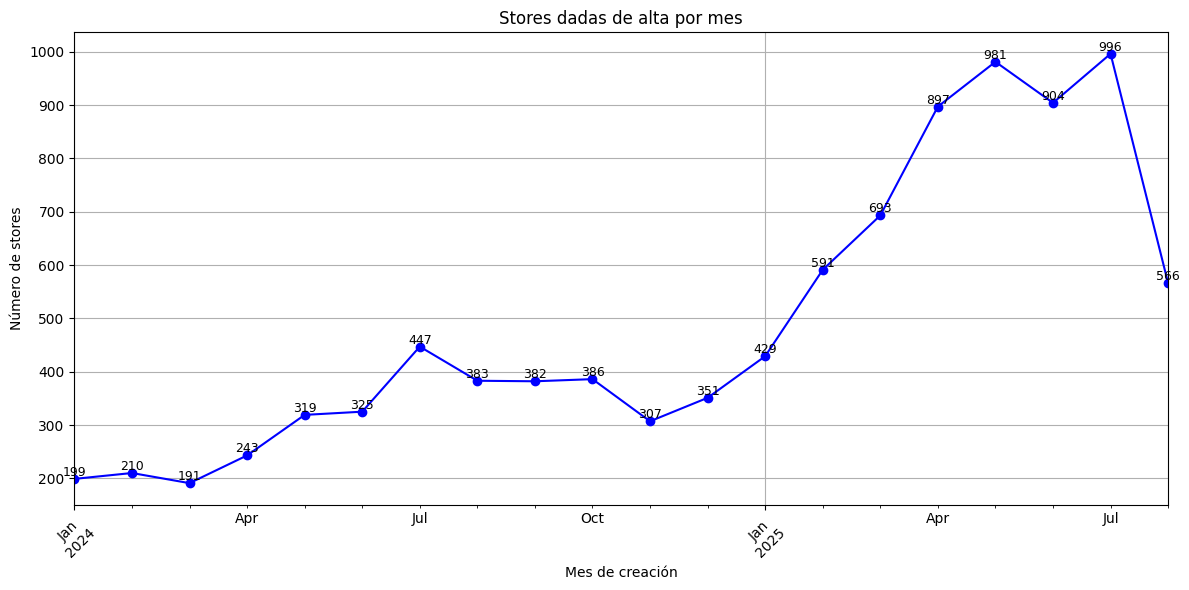

In [662]:
# Grafico de stores dados de alta por mes de creación (gráfico de puntos que se contectan con linea y el punto tiene un label con el valor exacto)
creation_counts = df_stores[df_stores['created_date'] < '09-01-2025']['created_date'].dt.to_period('M').value_counts().sort_index()
plt.figure(figsize=(12, 6))
creation_counts.plot(kind='line', marker='o', color='blue')
for i, count in enumerate(creation_counts):
    plt.text(creation_counts.index[i].to_timestamp(), count, str(count), fontsize=9, ha='center', va='bottom')
plt.title('Stores dadas de alta por mes')
plt.xlabel('Mes de creación')
plt.ylabel('Número de stores')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Análisis de cohorte
Relación entre antiguedad de la store en el sistema y su caida o no caida en churn

In [712]:
df = monthly_full.copy()

df['cohort_month'] = pd.to_datetime(df['created_date']).dt.to_period('M')

# --- Antigüedad en meses (cohort_index) ---
df['cohort_index'] = (
    (df['period_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['period_month'].dt.month - df['cohort_month'].dt.month)
)
df = df[df['cohort_index'] >= 0]

# definir active usando churn (1 si no churn, 0 si churn), si churn es NaN (antes de 1ra venta) se considera activo (1)
df['active'] = np.where(df['churn'].isna(), 1, 1 - df['churn'])

# --- Cohort size (tamaño inicial) ---
cohort_size = (
    df[df['cohort_index'] == 0]
    .groupby('cohort_month')['store_id']
    .nunique()
)

# conteos activos por cohorte x mes (sumamos la columna active)
active_counts = (
    df.groupby(['cohort_month','cohort_index'])['active']
    .sum()
    .unstack(fill_value=0)
)

# tasa de retención = active_counts / cohort_size
retention = active_counts.divide(cohort_size, axis=0)

In [714]:
def _cohort_max_age_from_df(df):
    """
    Devuelve una Series indexed by cohort_month con el mayor cohort_index observado
    para cada cohorte.
    """
    return df.groupby('cohort_month')['cohort_index'].max()

def plot_cohort_matrix(matrix: pd.DataFrame, 
                       cohort_max_age: pd.Series,
                       title: str,
                       cbar_label: str,
                       is_percentage: bool = False,
                       cmap_colors=None):
    """
    Dibuja heatmap tipo 'matriz de cohortes' con:
      - colormap rojo->amarillo->verde por defecto (puedes pasar cmap_colors)
      - celdas posteriores al último age observado por cohorte en blanco
      - anotaciones: ints si no es porcentaje, '12%' si es porcentaje
    """
    if cmap_colors is None:
        cmap_colors = ["#e74c3c","#f6d55c","#a3d977","#2ecc71"]  # rojo -> amarillo -> verde

    # data: si es porcentaje esperamos 0..1 en matrix; convertimos a 0..100 para mostrar colorbar en %
    data = matrix.values.astype(float)
    if is_percentage:
        display_data = data * 100.0
    else:
        display_data = data.copy()

    # construir máscara: True donde queremos ocultar (futuras edades > max_age para esa cohorte)
    n_rows, n_cols = display_data.shape
    mask = np.zeros_like(display_data, dtype=bool)

    # matrix.index contiene cohort_month Period[M]; cohort_max_age keyed by same type
    for i, cohort in enumerate(matrix.index):
        max_age = cohort_max_age.get(cohort, np.nan)
        if pd.isna(max_age):
            # si no hay info, ocultamos todas las columnas > -1 (o dejamos visibles 0)
            mask[i, :] = True
        else:
            # ocultar columnas con index > max_age
            mask[i, int(max_age)+1 : ] = True

    # también ocultar NaNs originales
    mask = mask | np.isnan(display_data)

    # crear masked array (imshow respetará mask)
    mdata = np.ma.array(display_data, mask=mask)

    # figure
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(matrix))))
    vmax = np.nanmax(display_data[~mask]) if np.any(~mask) else 1.0
    norm = Normalize(vmin=0, vmax=max(vmax, 1.0))

    cmap = LinearSegmentedColormap.from_list("red_to_green", cmap_colors)
    im = ax.imshow(mdata, aspect="auto", norm=norm, cmap=cmap)
    im.cmap.set_bad("white")  # masked values painted white

    # y labels (cohort month) en formato 'Jan-2024'
    ylabels = [idx.to_timestamp().strftime("%b-%Y") for idx in matrix.index]
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(ylabels)

    # x labels (ages)
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(matrix.columns.tolist())

    # grid discreto entre celdas
    ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.25)
    ax.tick_params(axis='both', which='both', length=0)

    ax.set_title(title, fontsize=14, weight='bold', pad=12)
    ax.set_xlabel("Meses desde creación")
    ax.set_ylabel("Mes de alta (cohorte)")

    # Anotar números (solo donde no está enmascarado)
    for i in range(n_rows):
        for j in range(n_cols):
            if mask[i, j]:
                continue
            val = display_data[i, j]
            if is_percentage:
                # mostrar con porcentaje sin decimales
                txt = f"{int(round(val))}%"
            else:
                txt = f"{int(val)}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color="black")

    # colorbar con etiqueta
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel(cbar_label, rotation=90)

    plt.tight_layout()
    plt.show()

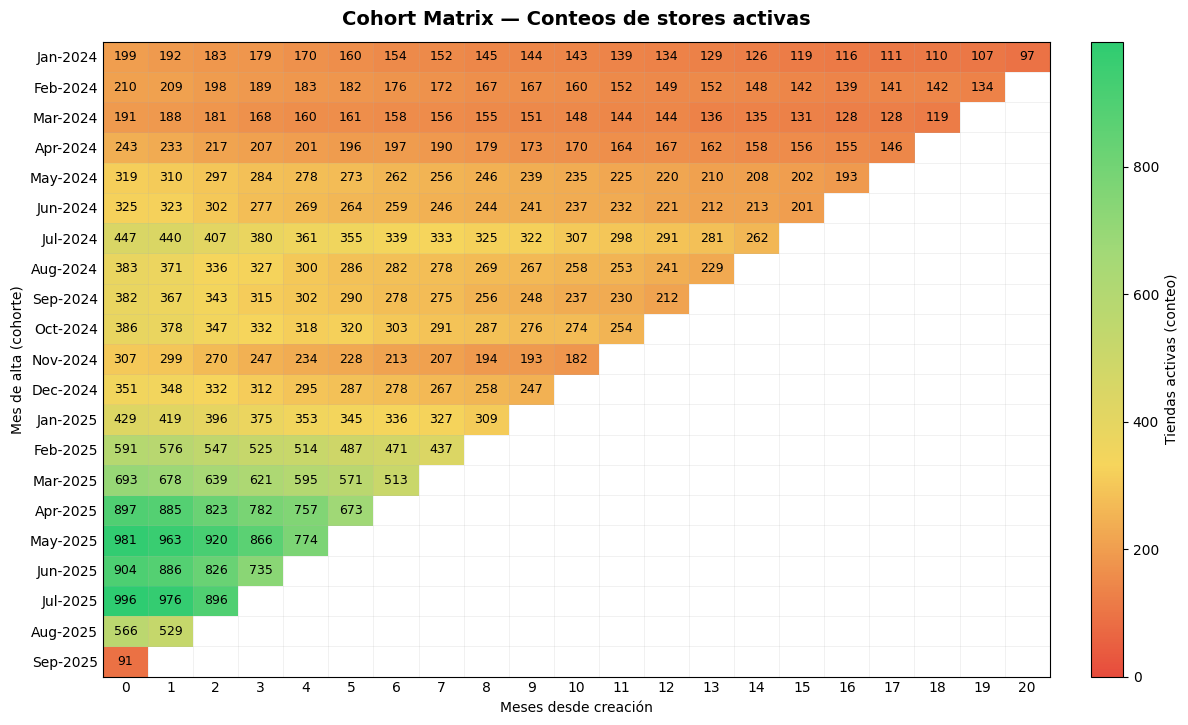

In [715]:
# obtener max age por cohorte desde tu df (mismo df que usaste para generar active_counts/retention)
cohort_max_age = _cohort_max_age_from_df(df)  # devuelve Series indexed by cohort_month

# Plot conteos (counts)
plot_cohort_matrix(
    matrix=active_counts,
    cohort_max_age=cohort_max_age,
    title="Cohort Matrix — Conteos de stores activas",
    cbar_label="Tiendas activas (conteo)",
    is_percentage=False,
    cmap_colors=["#e74c3c","#f6d55c","#a3d977","#2ecc71"]  # rojo->amarillo->verde
)

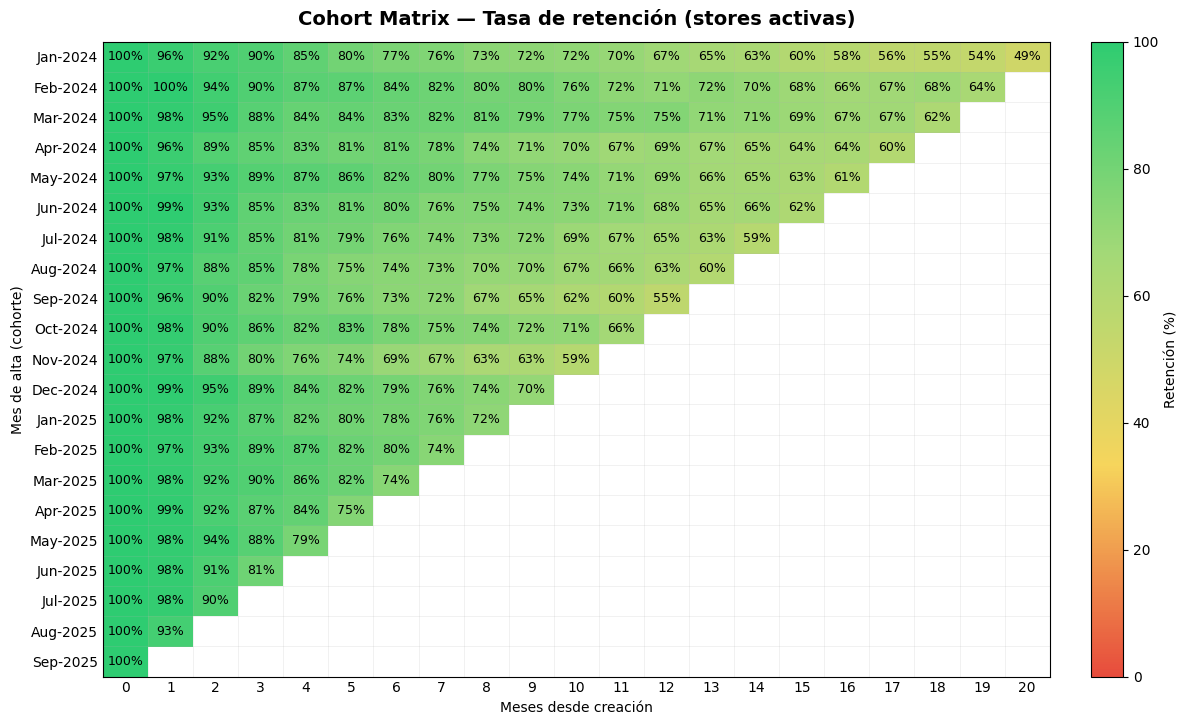

In [716]:
# Plot tasas (percent)
# retention viene en 0..1; pasamos is_percentage=True
plot_cohort_matrix(
    matrix=retention,
    cohort_max_age=cohort_max_age,
    title="Cohort Matrix — Tasa de retención (stores activas)",
    cbar_label="Retención (%)",
    is_percentage=True,
    cmap_colors=["#e74c3c","#f6d55c","#a3d977","#2ecc71"]
)

##### Supervivencia y probabilidades

In [687]:
# Kaplan–Meier: supervivencia (seguir activo) desde created_date

# -------------------------
# 1) Preparar tabla de tiempo hasta primer churn por store
# -------------------------
# Asegurarnos de tipos
df = monthly_full.copy()

df['created_period'] = pd.to_datetime(df['created_date']).dt.to_period('M')

# último periodo observado global (para censura)
last_period = df['period_month'].max()

# Para cada store: buscar el primer periodo >= created_period con churn == 1
def first_churn_info(g):
    # g: filas de un store (varios period_month)
    g = g.sort_values('period_month')
    # filtrar observaciones desde created_period en adelante (por si hay basura anterior)
    created_p = g['created_period'].iat[0]
    g = g[g['period_month'] >= created_p]
    # primer periodo con churn == 1
    churn_rows = g.loc[g['churn'] == 1, 'period_month']
    if not churn_rows.empty:
        event_period = churn_rows.iloc[0]
        event_observed = 1
    else:
        event_period = g['period_month'].max()  # censurado al último mes observado de la tienda
        event_observed = 0
    # duration en meses (entero >= 0)
    duration = (event_period.year - created_p.year) * 12 + (event_period.month - created_p.month)
    return pd.Series({
        'store_id': g['store_id'].iat[0],
        'created_period': created_p,
        'event_period': event_period,
        'duration_months': int(duration),
        'event_observed': int(event_observed),
        # conservar atributos estáticos para agrupar
        'segmento': g['segmento'].iat[0] if 'segmento' in g.columns else np.nan,
        'ciudad': g['ciudad'].iat[0] if 'ciudad' in g.columns else np.nan,
        'category': g['category'].iat[0] if 'category' in g.columns else np.nan,
        'barrio': g['barrio'].iat[0] if 'barrio' in g.columns else np.nan
        
    })

# Aplicar groupby (uno por tienda)
time_to_event = df.groupby('store_id', observed=True).apply(first_churn_info).reset_index(drop=True)

/var/folders/3y/gthkm3q95_s8ph7_t5zg1wb00000gn/T/ipykernel_3217/3925126418.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_to_event = df.groupby('store_id', observed=True).apply(first_churn_info).reset_index(drop=True)


In [688]:
# sanity check
print("N stores:", time_to_event['store_id'].nunique())
print("Durations: min/max", time_to_event['duration_months'].min(), time_to_event['duration_months'].max())
print("Events observed (number of stores with churn):", int(time_to_event['event_observed'].sum()))

N stores: 9891
Durations: min/max 0 20
Events observed (number of stores with churn): 2944


- Supervivencia por segmento

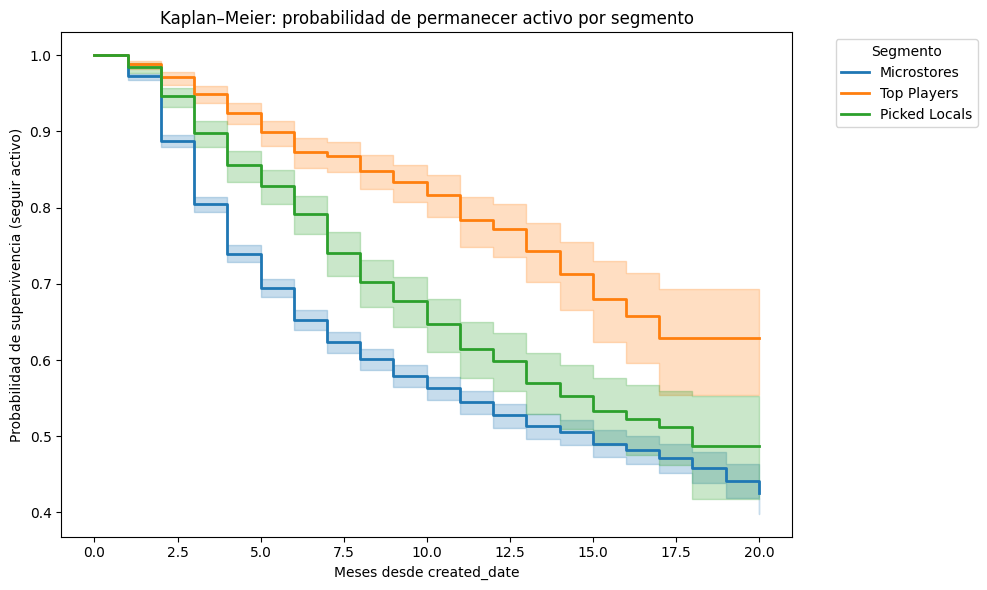

In [717]:
# -------------------------
# 2) Kaplan–Meier por segmento (ejemplo) y por ciudad (top N)
# -------------------------
kmf = KaplanMeierFitter()

# (A) Curvas por segmento (todas las categorías con >min_n stores)
min_n = 30   # umbral para plotear un segmento (evitar ruido)
segments_counts = time_to_event.groupby('segmento')['store_id'].nunique().sort_values(ascending=False)
segments_to_plot = segments_counts[segments_counts >= min_n].index.tolist()

plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=len(segments_to_plot))
for seg, col in zip(segments_to_plot, palette):
    mask = time_to_event['segmento'] == seg
    durations = time_to_event.loc[mask, 'duration_months']
    events = time_to_event.loc[mask, 'event_observed']
    kmf.fit(durations, event_observed=events, label=str(seg))
    kmf.plot_survival_function(ci_show=True, linewidth=2, color=col)
plt.title("Kaplan–Meier: probabilidad de permanecer activo por segmento")
plt.xlabel("Meses desde created_date")
plt.ylabel("Probabilidad de supervivencia (seguir activo)")
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Supervivencia por ciudad

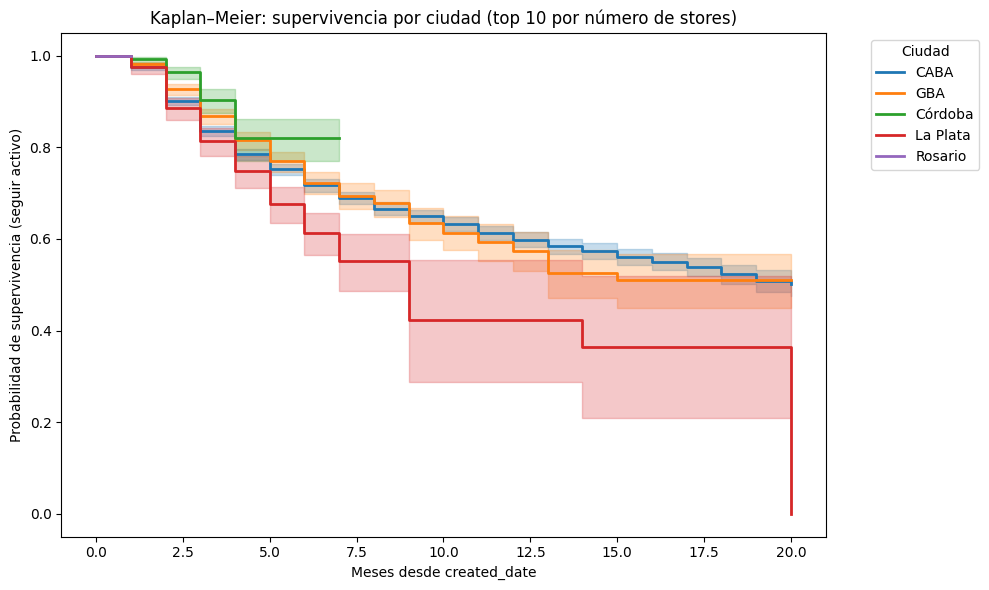

In [690]:
# (B) Curvas por ciudad: plotear top-N ciudades por número de stores
top_n = 10
city_counts = time_to_event['ciudad'].value_counts().nlargest(top_n)
cities_to_plot = city_counts.index.tolist()

plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=len(cities_to_plot))
for c, col in zip(cities_to_plot, palette):
    mask = time_to_event['ciudad'] == c
    durations = time_to_event.loc[mask, 'duration_months']
    events = time_to_event.loc[mask, 'event_observed']
    kmf.fit(durations, event_observed=events, label=str(c))
    kmf.plot_survival_function(ci_show=True, linewidth=2, color=col)
plt.title(f"Kaplan–Meier: supervivencia por ciudad (top {top_n} por número de stores)")
plt.xlabel("Meses desde created_date")
plt.ylabel("Probabilidad de supervivencia (seguir activo)")
plt.legend(title='Ciudad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Supervivencia por categoria de comida

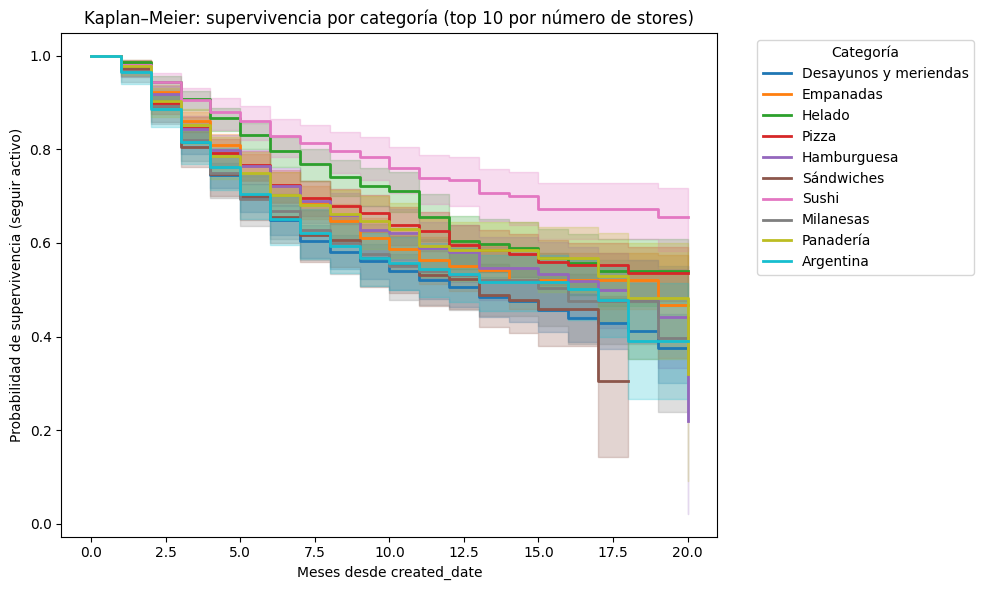

In [691]:
# (C) Curvas por categoria: plotear top-N categorias por número de stores
category_counts = time_to_event['category'].value_counts().nlargest(top_n)
categories_to_plot = category_counts.index.tolist()

plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=len(categories_to_plot))
for c, col in zip(categories_to_plot, palette):
    mask = time_to_event['category'] == c
    durations = time_to_event.loc[mask, 'duration_months']
    events = time_to_event.loc[mask, 'event_observed']
    kmf.fit(durations, event_observed=events, label=str(c))
    kmf.plot_survival_function(ci_show=True, linewidth=2, color=col)
plt.title(f"Kaplan–Meier: supervivencia por categoría (top {top_n} por número de stores)")
plt.xlabel("Meses desde created_date")
plt.ylabel("Probabilidad de supervivencia (seguir activo)")
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Supervivencia por barrio CABA

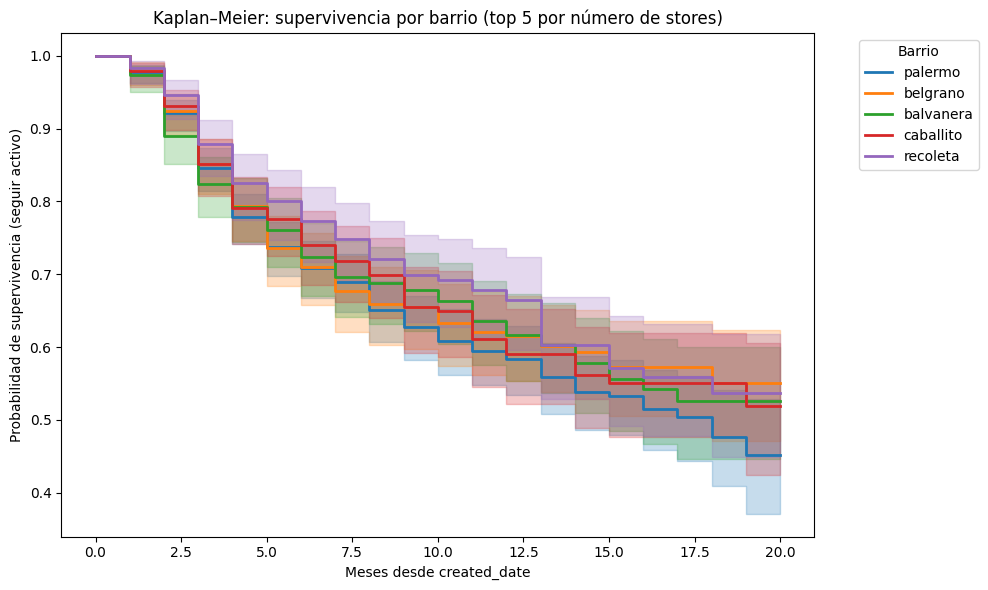

In [699]:
# (D) Curvas por barrio (CABA): plotear top-N barrios por número de stores
top_n = 5
barrio_caba_counts = time_to_event[time_to_event['ciudad'] == 'CABA']['barrio'].value_counts().nlargest(top_n)
barrios_to_plot = barrio_caba_counts.index.tolist()

plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=len(barrios_to_plot))
for c, col in zip(barrios_to_plot, palette):
    mask = time_to_event['barrio'] == c
    durations = time_to_event.loc[mask, 'duration_months']
    events = time_to_event.loc[mask, 'event_observed']
    kmf.fit(durations, event_observed=events, label=str(c))
    kmf.plot_survival_function(ci_show=True, linewidth=2, color=col)
plt.title(f"Kaplan–Meier: supervivencia por barrio (top {top_n} por número de stores)")
plt.xlabel("Meses desde created_date")
plt.ylabel("Probabilidad de supervivencia (seguir activo)")
plt.legend(title='Barrio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [697]:
barrio_caba_counts

barrio
palermo      628
belgrano     365
balvanera    342
caballito    341
recoleta     302
Name: count, dtype: int64

#### Relación entre ubicación y churn
- Evolucion temporal del churn por ubicación

In [725]:
# ...en cualquier celda de tu notebook...
# Conteo de stores únicos por ciudad
city_counts = monthly_full.groupby('ciudad')['store_id'].nunique().reset_index(name='count')

# Porcentaje sobre el total de stores únicos
total_stores = monthly_full['store_id'].nunique()
city_counts['percentage'] = (city_counts['count'] / total_stores * 100).round(2)

# Mostrar resultado ordenado por count descendente
city_counts.sort_values('count', ascending=False)

,ciudad,count,percentage
0,CABA,5205,52.62
2,GBA,1952,19.74
1,Córdoba,894,9.04
3,La Plata,729,7.37
4,Rosario,9,0.09


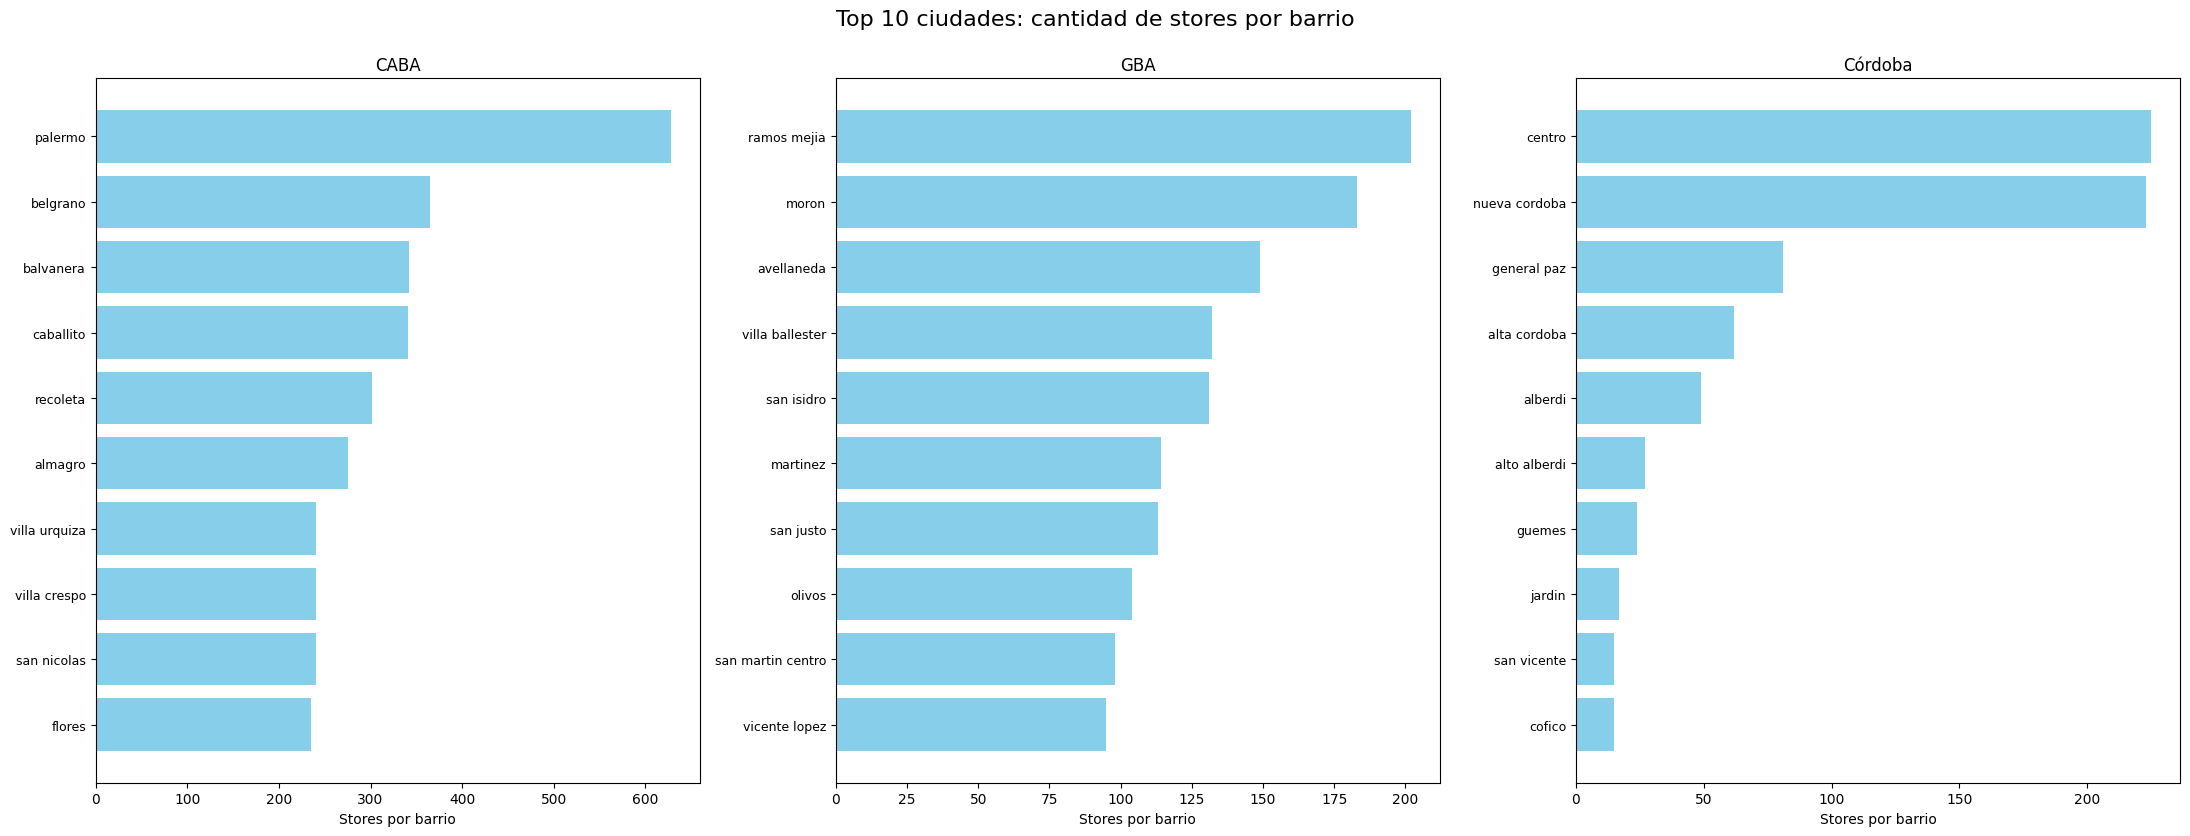

In [729]:
# Top 10 ciudades por cantidad de stores únicos
top_cities = monthly_full[monthly_full['ciudad'].notnull() & ~monthly_full['ciudad'].isin(['La Plata', 'Rosario'])].groupby('ciudad')['store_id'].nunique().nlargest(10).index.tolist()

# Para cada ciudad, obtener conteo de stores por barrio
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 8), sharex=False)
axes = axes.flatten()

for i, ciudad in enumerate(top_cities):
    # Filtrar barrios y contar stores únicos por barrio
    df_city = monthly_full[monthly_full['ciudad'] == ciudad]
    barrio_counts = df_city.groupby('barrio')['store_id'].nunique().sort_values(ascending=True)
    # Tomar solo los top 10 barrios si hay muchos
    barrio_counts = barrio_counts.tail(10)
    axes[i].barh(barrio_counts.index, barrio_counts.values, color='skyblue')
    axes[i].set_title(ciudad)
    axes[i].set_xlabel('Stores por barrio')
    axes[i].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.suptitle('Top 10 ciudades: cantidad de stores por barrio', fontsize=16, y=1.04)
plt.show()

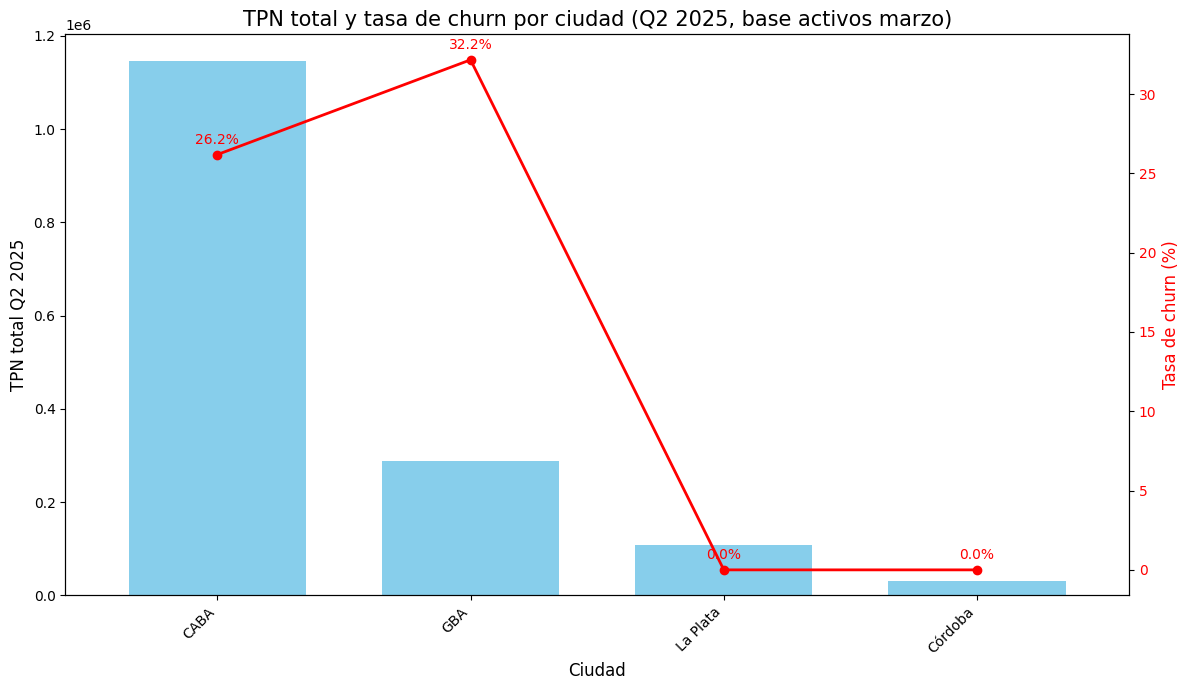

In [738]:
# Filtrar Q2 2025 (abril, mayo, junio)
periodos_q2 = [pd.Period('2025-04', freq='M'), pd.Period('2025-05', freq='M'), pd.Period('2025-06', freq='M')]
periodo_marzo = pd.Period('2025-03', freq='M')
df_q2 = monthly_full[monthly_full['period_month'].isin(periodos_q2) & (monthly_full['ciudad'] != 'Rosario')]

# 1. Stores activos en marzo (a riesgo de entrar en churn en Q2)
df_marzo = monthly_full[(monthly_full['period_month'] == periodo_marzo) & (monthly_full['ciudad'] != 'Rosario')]
stores_activos_marzo = df_marzo[df_marzo['tpn'] > 0][['store_id', 'ciudad']].drop_duplicates()

# 2. Stores que entraron en churn en Q2 (churn_unique == 1, solo contar una vez por store)
stores_churn_q2 = df_q2[df_q2['churn_unique'] == 1][['store_id', 'ciudad']].drop_duplicates()

# 3. Calcular denominador y nominador por ciudad
activos_por_ciudad = stores_activos_marzo.groupby('ciudad')['store_id'].nunique()
churned_por_ciudad = stores_churn_q2.groupby('ciudad')['store_id'].nunique()

# 4. TPN total por ciudad en Q2
tpn_por_ciudad = df_q2.groupby('ciudad')['tpn'].sum().sort_values(ascending=False)

# 5. Churn rate usando los activos de marzo como base
churn_rate = (churned_por_ciudad / activos_por_ciudad * 100).reindex(tpn_por_ciudad.index).fillna(0)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras de TPN
tpn_por_ciudad.plot(kind='bar', ax=ax1, color='skyblue', width=0.7)
ax1.set_ylabel('TPN total Q2 2025', color='black', fontsize=12)
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticklabels(tpn_por_ciudad.index, rotation=45, ha='right')

# Eje secundario para churn rate
ax2 = ax1.twinx()
ax2.plot(tpn_por_ciudad.index, churn_rate.values, color='red', marker='o', linewidth=2, label='Churn rate (%)')
ax2.set_ylabel('Tasa de churn (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Anotar churn rate encima de cada punto
for i, val in enumerate(churn_rate.values):
    ax2.text(i, val + 0.5, f"{val:.1f}%", color='red', ha='center', va='bottom', fontsize=10)

plt.title('TPN total y tasa de churn por ciudad (Q2 2025, base activos marzo)', fontsize=15)
plt.tight_layout()
plt.show()

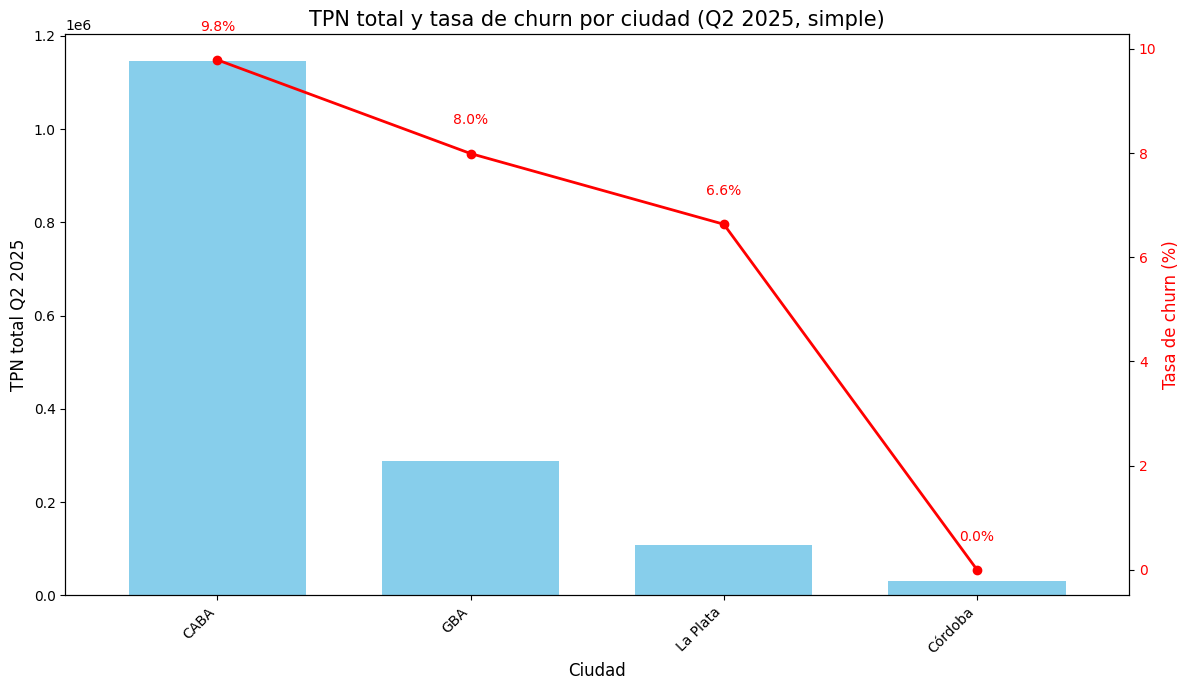

In [744]:
# Tasa de churn simple: stores con churn_unique en Q2 / total de stores en Q2 (sin duplicados)

# Filtrar Q2 2025 (abril, mayo, junio)
periodos_q2 = [pd.Period('2025-04', freq='M'), pd.Period('2025-05', freq='M'), pd.Period('2025-06', freq='M')]
df_q2 = monthly_full[monthly_full['period_month'].isin(periodos_q2) & (monthly_full['ciudad'] != 'Rosario')]

# 1. Total de stores únicos en Q2 por ciudad
stores_q2 = df_q2[['store_id', 'ciudad']].drop_duplicates()
total_stores_q2 = stores_q2.groupby('ciudad')['store_id'].nunique()

# 2. Stores que entraron en churn en Q2 (churn_unique == 1, solo contar una vez por store)
stores_churn_q2 = df_q2[df_q2['churn_unique'] == 1][['store_id', 'ciudad']].drop_duplicates()
churned_por_ciudad = stores_churn_q2.groupby('ciudad')['store_id'].nunique()

# 3. TPN total por ciudad en Q2
tpn_por_ciudad = df_q2.groupby('ciudad')['tpn'].sum().sort_values(ascending=False)

# 4. Churn rate simple
churn_rate_simple = (churned_por_ciudad / total_stores_q2 * 100).reindex(tpn_por_ciudad.index).fillna(0)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 7))

tpn_por_ciudad.plot(kind='bar', ax=ax1, color='skyblue', width=0.7)
ax1.set_ylabel('TPN total Q2 2025', color='black', fontsize=12)
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticklabels(tpn_por_ciudad.index, rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(tpn_por_ciudad.index, churn_rate_simple.values, color='red', marker='o', linewidth=2, label='Churn rate (%)')
ax2.set_ylabel('Tasa de churn (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

for i, val in enumerate(churn_rate_simple.values):
    ax2.text(i, val + 0.5, f"{val:.1f}%", color='red', ha='center', va='bottom', fontsize=10)

plt.title('TPN total y tasa de churn por ciudad (Q2 2025, simple)', fontsize=15)
plt.tight_layout()
plt.show()

#### Relación entre segmento y churn
- Evolucion temporal del churn por segmento

In [ ]:
df_stores['segmento'].value_counts().reset_index()

pd.DataFrame({'count': df_stores['status'].value_counts(dropna=True), 'percentage': (df_stores['status'].value_counts(normalize=True, dropna=True) * 100).round(2)})

,segmento,count
0,Microstores,6951
1,Top Players,1604
2,Picked Locals,1336


#### Relación entre categoria de comida y churn
- Evolucion temporal del churn por categoria de comida

#### Relación entre conectividad y churn
- Análisis temporal y atemporal de la relación entre las variables de conectividad y churn